# Etapa 2 - Análise Exploratória de Dados (EDA)

## Objetivo
Entender o comportamento dos dados, identificar padrões e correlações que guiam a preparação e modelagem.

## O que vamos fazer?
1. Carregar dados já validados
2. Explorar estatísticas descritivas
3. Analisar comportamento do Churn
4. Criar visualizações
5. Documentar insights

In [33]:
# %% [markdown]
# # Etapa 2 - Análise Exploratória de Dados (EDA)
#
# Nesta etapa vamos analisar o comportamento dos dados antes da modelagem.
#
# Objetivos:
# - entender a estrutura do dataset;
# - analisar a distribuição de Churn;
# - identificar valores ausentes;
# - identificar possíveis inconsistências;
# - analisar variáveis numéricas e categóricas;
# - identificar relações relevantes com Churn;
# - gerar informações que orientarão o pré-processamento e a modelagem.

# %%

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

print("✓ Bibliotecas importadas com sucesso!")

✓ Bibliotecas importadas com sucesso!


In [34]:
# %%
# CONFIGURAÇÃO DO PROJETO

try:
    notebook_dir = Path.cwd()

    if notebook_dir.name == "notebooks":
        project_root = notebook_dir.parent
    else:
        project_root = notebook_dir

except Exception:
    project_root = Path.cwd()

# Diretórios
data_processed_dir = project_root / "data" / "processed"
artifacts_dir = project_root / "artifacts"
artifacts_plots_dir = artifacts_dir / "plots"
artifacts_tables_dir = artifacts_dir / "tables"
reports_dir = project_root / "reports"

# Criar diretórios
artifacts_plots_dir.mkdir(parents=True, exist_ok=True)
artifacts_tables_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("CONFIGURAÇÃO DO PROJETO")
print("=" * 60)

print(f"\nDiretório do projeto:")
print(project_root)

print(f"\nDiretório de gráficos:")
print(artifacts_plots_dir)

print(f"\nDiretório de tabelas:")
print(artifacts_tables_dir)

print("\n✓ Diretórios configurados com sucesso!")

CONFIGURAÇÃO DO PROJETO

Diretório do projeto:
c:\Temp\telco-churn-ml

Diretório de gráficos:
c:\Temp\telco-churn-ml\artifacts\plots

Diretório de tabelas:
c:\Temp\telco-churn-ml\artifacts\tables

✓ Diretórios configurados com sucesso!


In [35]:
# %%
# CARREGAMENTO DOS DADOS

input_file = data_processed_dir / "01_raw_validated.csv"

print("=" * 60)
print("CARREGAMENTO DO DATASET")
print("=" * 60)

print(f"\nArquivo esperado:")
print(input_file)

print(f"\nArquivo encontrado: {input_file.exists()}")

if not input_file.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {input_file}"
    )

df = pd.read_csv(input_file)

print("\n✓ Dataset carregado com sucesso!")

print(f"\nDimensões:")
print(f"  Linhas:  {df.shape[0]:,}")
print(f"  Colunas: {df.shape[1]}")

print("\nPrimeiras 5 linhas:")
display(df.head())

CARREGAMENTO DO DATASET

Arquivo esperado:
c:\Temp\telco-churn-ml\data\processed\01_raw_validated.csv

Arquivo encontrado: True

✓ Dataset carregado com sucesso!

Dimensões:
  Linhas:  7,043
  Colunas: 21

Primeiras 5 linhas:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
# %%
# ESTRUTURA DO DATASET

print("=" * 60)
print("ESTRUTURA DO DATASET")
print("=" * 60)

print("\nDimensões:")
print(df.shape)

print("\nColunas:")
for col in df.columns:
    print(f" - {col}")

print("\nTipos de dados:")
print(df.dtypes)

ESTRUTURA DO DATASET

Dimensões:
(7043, 21)

Colunas:
 - customerID
 - gender
 - SeniorCitizen
 - Partner
 - Dependents
 - tenure
 - PhoneService
 - MultipleLines
 - InternetService
 - OnlineSecurity
 - OnlineBackup
 - DeviceProtection
 - TechSupport
 - StreamingTV
 - StreamingMovies
 - Contract
 - PaperlessBilling
 - PaymentMethod
 - MonthlyCharges
 - TotalCharges
 - Churn

Tipos de dados:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [37]:
# %%
# VERIFICAÇÃO DA QUALIDADE DOS DADOS

print("=" * 60)
print("VERIFICAÇÃO DA QUALIDADE DOS DADOS")
print("=" * 60)

# Valores ausentes
print("\n1. VALORES AUSENTES")
print("-" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Valores_Ausentes": missing,
    "Percentual": missing_pct.round(2)
})

missing_table = missing_table[
    missing_table["Valores_Ausentes"] > 0
]

if missing_table.empty:
    print("✓ Nenhum valor ausente encontrado.")
else:
    print(missing_table)

# Strings vazias
print("\n2. VALORES VAZIOS")
print("-" * 60)

empty_values = {}

for col in df.select_dtypes(include="object").columns:
    count = (df[col].astype(str).str.strip() == "").sum()

    if count > 0:
        empty_values[col] = count

if empty_values:
    for col, count in empty_values.items():
        print(f"{col}: {count}")
else:
    print("✓ Nenhuma string vazia encontrada.")

# Duplicatas
print("\n3. DUPLICATAS")
print("-" * 60)

duplicates = df.duplicated().sum()

print(f"Linhas duplicadas: {duplicates}")

# CustomerID
print("\n4. CUSTOMER ID")
print("-" * 60)

if "customerID" in df.columns:

    duplicated_ids = df["customerID"].duplicated().sum()

    print(f"CustomerID duplicados: {duplicated_ids}")

# TotalCharges
print("\n5. TOTAL CHARGES")
print("-" * 60)

total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

invalid_mask = (
    total_charges_numeric.isna()
    & df["TotalCharges"].notna()
)

invalid_count = invalid_mask.sum()

print(f"Valores não convertidos: {invalid_count}")

if invalid_count > 0:
    print("\nExemplos:")
    print(df.loc[invalid_mask, "TotalCharges"].head(10))

print("\n✓ Verificação concluída.")

VERIFICAÇÃO DA QUALIDADE DOS DADOS

1. VALORES AUSENTES
------------------------------------------------------------
✓ Nenhum valor ausente encontrado.

2. VALORES VAZIOS
------------------------------------------------------------
TotalCharges: 11

3. DUPLICATAS
------------------------------------------------------------
Linhas duplicadas: 0

4. CUSTOMER ID
------------------------------------------------------------
CustomerID duplicados: 0

5. TOTAL CHARGES
------------------------------------------------------------
Valores não convertidos: 11

Exemplos:
488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
Name: TotalCharges, dtype: object

✓ Verificação concluída.


In [38]:
# %%
# ESTATÍSTICAS DESCRITIVAS

print("=" * 60)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 60)

print("\nResumo estatístico das variáveis numéricas:")

display(
    df.describe().round(2)
)

ESTATÍSTICAS DESCRITIVAS

Resumo estatístico das variáveis numéricas:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [39]:
# %%
# PREPARAÇÃO DAS VARIÁVEIS NUMÉRICAS PARA A EDA

df_numeric = df.copy()

# Converter TotalCharges
df_numeric["TotalCharges"] = pd.to_numeric(
    df_numeric["TotalCharges"],
    errors="coerce"
)

# Converter Churn para 0/1
df_numeric["Churn"] = (
    df_numeric["Churn"] == "Yes"
).astype(int)

# Identificar todas as colunas numéricas
numeric_cols = df_numeric.select_dtypes(
    include=[np.number]
).columns.tolist()

print("=" * 60)
print("VARIÁVEIS NUMÉRICAS")
print("=" * 60)

for col in numeric_cols:
    print(f" - {col}")

print("\n✓ Variáveis numéricas identificadas.")

VARIÁVEIS NUMÉRICAS
 - SeniorCitizen
 - tenure
 - MonthlyCharges
 - TotalCharges
 - Churn

✓ Variáveis numéricas identificadas.


In [40]:
# %%
# ANÁLISE DA VARIÁVEL-ALVO — CHURN

print("=" * 60)
print("ANÁLISE DA VARIÁVEL-ALVO — CHURN")
print("=" * 60)

churn_counts = df["Churn"].value_counts()

churn_percent = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

churn_summary = pd.DataFrame({
    "Quantidade": churn_counts,
    "Percentual (%)": churn_percent.round(2)
})

print("\nDistribuição da variável Churn:")
print(churn_summary)

churn_rate = (
    df["Churn"] == "Yes"
).mean() * 100

print("\n" + "-" * 60)

print(f"Taxa geral de Churn: {churn_rate:.2f}%")
print(f"Taxa de permanência: {100 - churn_rate:.2f}%")

# Balanceamento
minority_class = churn_counts.min()
majority_class = churn_counts.max()

imbalance_ratio = (
    majority_class / minority_class
)

print("\n" + "-" * 60)
print("ANÁLISE DO BALANCEAMENTO")

print(f"Classe majoritária: {churn_counts.idxmax()}")
print(f"Classe minoritária: {churn_counts.idxmin()}")
print(
    f"Razão majoritária/minoritária: "
    f"{imbalance_ratio:.2f}"
)

if imbalance_ratio > 1.5:
    print(
        "⚠ Dataset apresenta desbalanceamento relevante."
    )
else:
    print(
        "✓ Dataset apresenta distribuição relativamente equilibrada."
    )

ANÁLISE DA VARIÁVEL-ALVO — CHURN

Distribuição da variável Churn:
       Quantidade  Percentual (%)
Churn                            
No           5174           73.46
Yes          1869           26.54

------------------------------------------------------------
Taxa geral de Churn: 26.54%
Taxa de permanência: 73.46%

------------------------------------------------------------
ANÁLISE DO BALANCEAMENTO
Classe majoritária: No
Classe minoritária: Yes
Razão majoritária/minoritária: 2.77
⚠ Dataset apresenta desbalanceamento relevante.


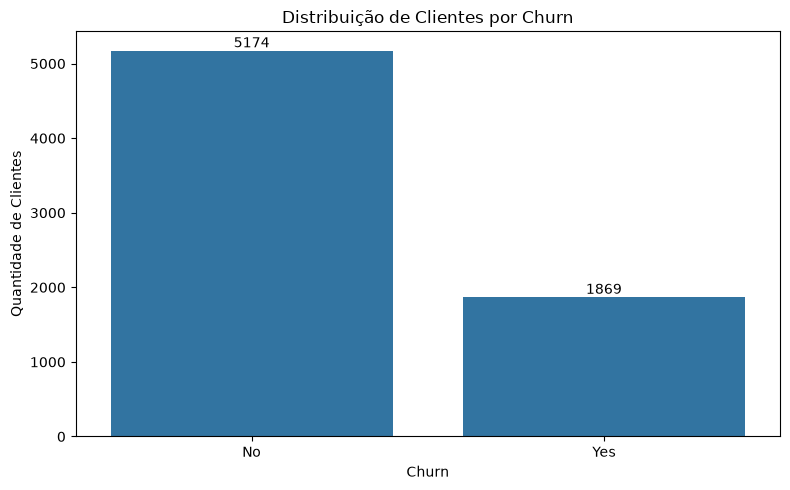


✓ Gráfico salvo em:
c:\Temp\telco-churn-ml\artifacts\plots\01_churn_distribution.png


In [41]:
# %%
# GRÁFICO — DISTRIBUIÇÃO DE CHURN

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Distribuição de Clientes por Churn")
plt.xlabel("Churn")
plt.ylabel("Quantidade de Clientes")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

output_path = (
    artifacts_plots_dir /
    "01_churn_distribution.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\n✓ Gráfico salvo em:")
print(output_path)

In [42]:
# %%
# ANÁLISE DE CHURN POR VARIÁVEIS CATEGÓRICAS

print("=" * 60)
print("TAXA DE CHURN POR VARIÁVEIS CATEGÓRICAS")
print("=" * 60)

eda_df = df.copy()

eda_df["TotalCharges"] = pd.to_numeric(
    eda_df["TotalCharges"],
    errors="coerce"
)

categorical_cols = eda_df.select_dtypes(
    include=["object"]
).columns.tolist()

categorical_cols = [
    col
    for col in categorical_cols
    if col not in ["customerID", "Churn"]
]

print(
    f"\nTotal de variáveis categóricas analisadas: "
    f"{len(categorical_cols)}"
)

for col in categorical_cols:
    print(f" - {col}")

churn_analysis = []

for col in categorical_cols:

    grouped = (
        eda_df.groupby(col)["Churn"]
        .apply(
            lambda x:
            (x == "Yes").mean() * 100
        )
        .sort_values(ascending=False)
    )

    for category, rate in grouped.items():

        total = (
            eda_df[col] == category
        ).sum()

        churn_count = (
            (eda_df[col] == category)
            &
            (eda_df["Churn"] == "Yes")
        ).sum()

        churn_analysis.append({
            "Variavel": col,
            "Categoria": category,
            "Clientes": total,
            "Churn": churn_count,
            "Taxa_Churn_%": rate
        })

churn_analysis_df = pd.DataFrame(
    churn_analysis
)

print("\n" + "-" * 60)
print("CATEGORIAS COM MAIOR TAXA DE CHURN")
print("-" * 60)

display(
    churn_analysis_df
    .sort_values(
        "Taxa_Churn_%",
        ascending=False
    )
    .head(20)
    .round(2)
)

TAXA DE CHURN POR VARIÁVEIS CATEGÓRICAS

Total de variáveis categóricas analisadas: 15
 - gender
 - Partner
 - Dependents
 - PhoneService
 - MultipleLines
 - InternetService
 - OnlineSecurity
 - OnlineBackup
 - DeviceProtection
 - TechSupport
 - StreamingTV
 - StreamingMovies
 - Contract
 - PaperlessBilling
 - PaymentMethod

------------------------------------------------------------
CATEGORIAS COM MAIOR TAXA DE CHURN
------------------------------------------------------------


,Variavel,Categoria,Clientes,Churn,Taxa_Churn_%
37,PaymentMethod,Electronic check,2365,1071,45.29
32,Contract,Month-to-month,3875,1655,42.71
11,InternetService,Fiber optic,3096,1297,41.89
14,OnlineSecurity,No,3498,1461,41.77
23,TechSupport,No,3473,1446,41.64
17,OnlineBackup,No,3088,1233,39.93
20,DeviceProtection,No,3095,1211,39.13
29,StreamingMovies,No,2785,938,33.68
35,PaperlessBilling,Yes,4171,1400,33.57
26,StreamingTV,No,2810,942,33.52


In [43]:
# %%
# SALVAR ANÁLISE CATEGÓRICA

categorical_output_path = (
    artifacts_tables_dir /
    "categorical_churn_analysis.csv"
)

churn_analysis_df.to_csv(
    categorical_output_path,
    index=False
)

print("✓ Análise categórica concluída.")
print("\nArquivo salvo em:")
print(categorical_output_path)

✓ Análise categórica concluída.

Arquivo salvo em:
c:\Temp\telco-churn-ml\artifacts\tables\categorical_churn_analysis.csv


In [44]:
# %%
# RANKING DAS CATEGORIAS POR TAXA DE CHURN

print("=" * 60)
print("RANKING DAS CATEGORIAS POR TAXA DE CHURN")
print("=" * 60)

ranking_churn = (
    churn_analysis_df
    .sort_values(
        "Taxa_Churn_%",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    ranking_churn[
        [
            "Variavel",
            "Categoria",
            "Clientes",
            "Churn",
            "Taxa_Churn_%"
        ]
    ].head(20).round(2)
)

RANKING DAS CATEGORIAS POR TAXA DE CHURN


,Variavel,Categoria,Clientes,Churn,Taxa_Churn_%
0,PaymentMethod,Electronic check,2365,1071,45.29
1,Contract,Month-to-month,3875,1655,42.71
2,InternetService,Fiber optic,3096,1297,41.89
3,OnlineSecurity,No,3498,1461,41.77
4,TechSupport,No,3473,1446,41.64
5,OnlineBackup,No,3088,1233,39.93
6,DeviceProtection,No,3095,1211,39.13
7,StreamingMovies,No,2785,938,33.68
8,PaperlessBilling,Yes,4171,1400,33.57
9,StreamingTV,No,2810,942,33.52


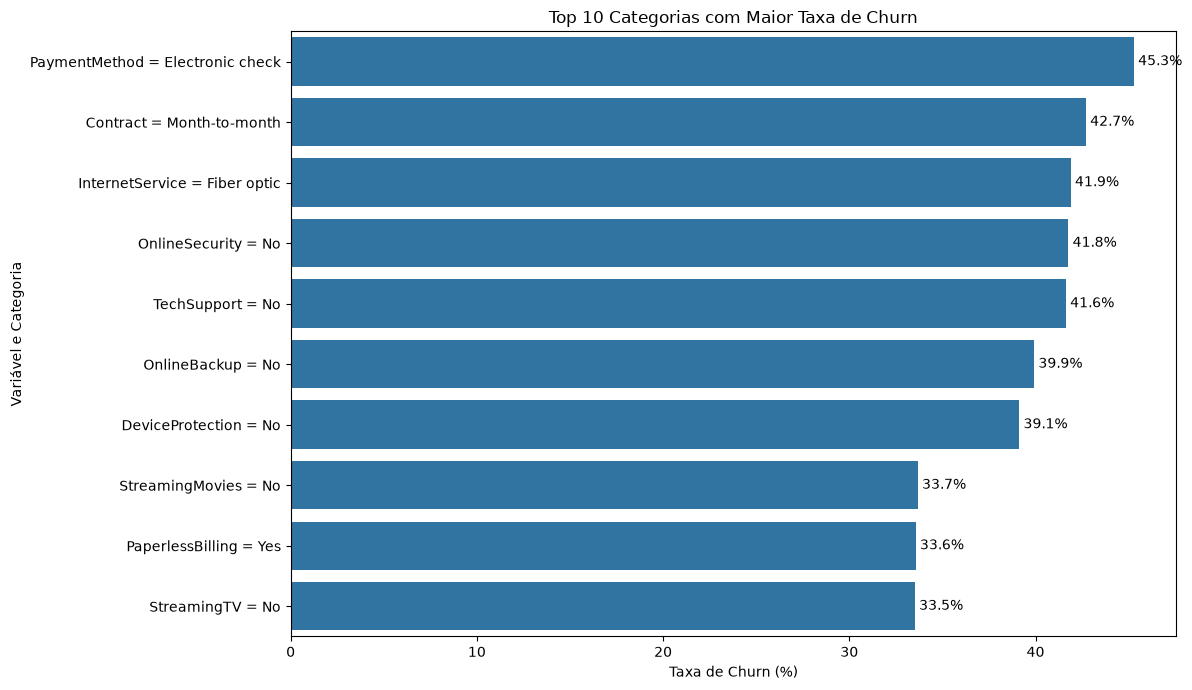


✓ Gráfico salvo em:
c:\Temp\telco-churn-ml\artifacts\plots\02_top_categories_churn.png


In [45]:
# %%
# GRÁFICO — TOP 10 CATEGORIAS COM MAIOR CHURN

top_10 = ranking_churn.head(10).copy()

top_10["Categoria_Label"] = (
    top_10["Variavel"]
    + " = "
    + top_10["Categoria"].astype(str)
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_10,
    x="Taxa_Churn_%",
    y="Categoria_Label"
)

plt.title(
    "Top 10 Categorias com Maior Taxa de Churn"
)

plt.xlabel("Taxa de Churn (%)")
plt.ylabel("Variável e Categoria")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()

output_path = (
    artifacts_plots_dir /
    "02_top_categories_churn.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\n✓ Gráfico salvo em:")
print(output_path)

In [46]:
# %%
# ANÁLISE DE CHURN POR VARIÁVEIS NUMÉRICAS

print("=" * 60)
print("ANÁLISE DE CHURN POR VARIÁVEIS NUMÉRICAS")
print("=" * 60)

# Variáveis numéricas originais relevantes
numeric_features_eda = [
    col
    for col in numeric_cols
    if col != "Churn"
]

print("\nVariáveis analisadas:")

for col in numeric_features_eda:
    print(f" - {col}")

numeric_churn_summary = (
    df_numeric
    .groupby("Churn")[numeric_features_eda]
    .mean()
    .round(2)
)

# Trocar 0/1 por No/Yes apenas para exibição
numeric_churn_summary.index = [
    "No" if value == 0 else "Yes"
    for value in numeric_churn_summary.index
]

print("\nMédias por Churn:")
display(numeric_churn_summary)

ANÁLISE DE CHURN POR VARIÁVEIS NUMÉRICAS

Variáveis analisadas:
 - SeniorCitizen
 - tenure
 - MonthlyCharges
 - TotalCharges

Médias por Churn:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
No,0.13,37.57,61.27,2555.34
Yes,0.25,17.98,74.44,1531.80


In [47]:
# %%
# DIFERENÇA ENTRE CLIENTES COM E SEM CHURN

print("=" * 60)
print("DIFERENÇA ENTRE CLIENTES COM E SEM CHURN")
print("=" * 60)

for col in numeric_features_eda:

    mean_no = df_numeric.loc[
        df_numeric["Churn"] == 0,
        col
    ].mean()

    mean_yes = df_numeric.loc[
        df_numeric["Churn"] == 1,
        col
    ].mean()

    difference = mean_yes - mean_no

    print(f"\n{col}")
    print(f"  Média - Churn No : {mean_no:.2f}")
    print(f"  Média - Churn Yes: {mean_yes:.2f}")
    print(f"  Diferença        : {difference:.2f}")

DIFERENÇA ENTRE CLIENTES COM E SEM CHURN

SeniorCitizen
  Média - Churn No : 0.13
  Média - Churn Yes: 0.25
  Diferença        : 0.13

tenure
  Média - Churn No : 37.57
  Média - Churn Yes: 17.98
  Diferença        : -19.59

MonthlyCharges
  Média - Churn No : 61.27
  Média - Churn Yes: 74.44
  Diferença        : 13.18

TotalCharges
  Média - Churn No : 2555.34
  Média - Churn Yes: 1531.80
  Diferença        : -1023.55


In [48]:
# %%
# SALVAR ANÁLISE NUMÉRICA

numeric_output_path = (
    artifacts_tables_dir /
    "numeric_churn_analysis.csv"
)

numeric_churn_summary.to_csv(
    numeric_output_path
)

print("✓ Análise numérica concluída.")

print("\nArquivo salvo em:")
print(numeric_output_path)

✓ Análise numérica concluída.

Arquivo salvo em:
c:\Temp\telco-churn-ml\artifacts\tables\numeric_churn_analysis.csv


In [49]:
# %%
# ANÁLISE DE CHURN POR FAIXA DE TENURE

print("=" * 60)
print("ANÁLISE DE CHURN POR FAIXA DE TENURE")
print("=" * 60)

df_tenure = df.copy()

df_tenure["tenure"] = pd.to_numeric(
    df_tenure["tenure"],
    errors="coerce"
)

df_tenure["tenure_group"] = pd.cut(
    df_tenure["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 meses",
        "7-12 meses",
        "13-24 meses",
        "25-48 meses",
        "49-72 meses"
    ]
)

tenure_analysis = (
    df_tenure
    .groupby(
        "tenure_group",
        observed=False
    )
    .agg(
        Clientes=("Churn", "count"),
        Churn=(
            "Churn",
            lambda x: (x == "Yes").sum()
        )
    )
)

tenure_analysis["Taxa_Churn_%"] = (
    tenure_analysis["Churn"]
    / tenure_analysis["Clientes"]
    * 100
).round(2)

display(tenure_analysis)

ANÁLISE DE CHURN POR FAIXA DE TENURE


,Clientes,Churn,Taxa_Churn_%
tenure_group,,,
0-6 meses,1481,784,52.94
7-12 meses,705,253,35.89
13-24 meses,1024,294,28.71
25-48 meses,1594,325,20.39
49-72 meses,2239,213,9.51


In [50]:
# %%
# ORDENAR E SALVAR ANÁLISE DE TENURE

print("=" * 60)
print("TAXA DE CHURN POR FAIXA DE TENURE")
print("=" * 60)

tenure_sorted = (
    tenure_analysis
    .sort_values(
        "Taxa_Churn_%",
        ascending=False
    )
)

display(tenure_sorted)

tenure_output_path = (
    artifacts_tables_dir /
    "tenure_churn_analysis.csv"
)

tenure_analysis.to_csv(
    tenure_output_path
)

print("\n✓ Análise de tenure concluída.")

print("\nArquivo salvo em:")
print(tenure_output_path)

TAXA DE CHURN POR FAIXA DE TENURE


,Clientes,Churn,Taxa_Churn_%
tenure_group,,,
0-6 meses,1481,784,52.94
7-12 meses,705,253,35.89
13-24 meses,1024,294,28.71
25-48 meses,1594,325,20.39
49-72 meses,2239,213,9.51



✓ Análise de tenure concluída.

Arquivo salvo em:
c:\Temp\telco-churn-ml\artifacts\tables\tenure_churn_analysis.csv


ANÁLISE UNIVARIADA - VARIÁVEIS NUMÉRICAS

Variáveis analisadas:
 - SeniorCitizen
 - tenure
 - MonthlyCharges
 - TotalCharges


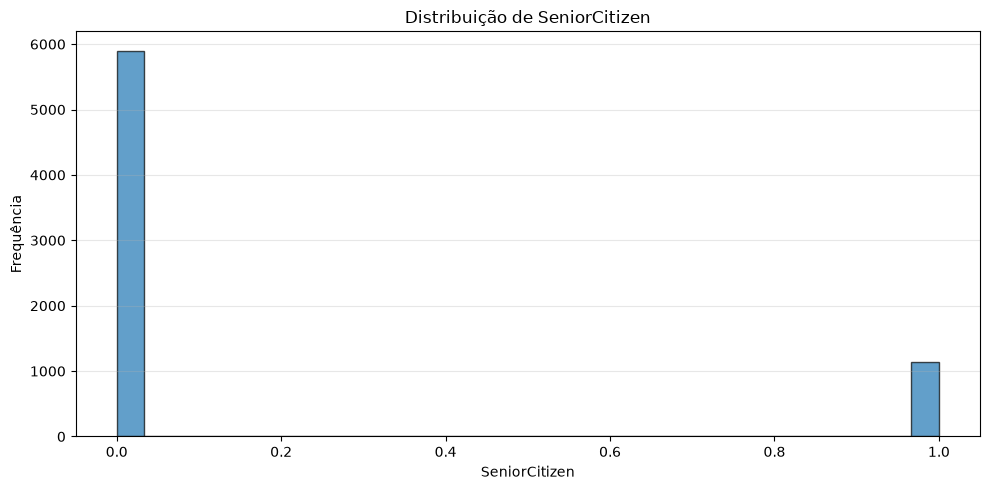

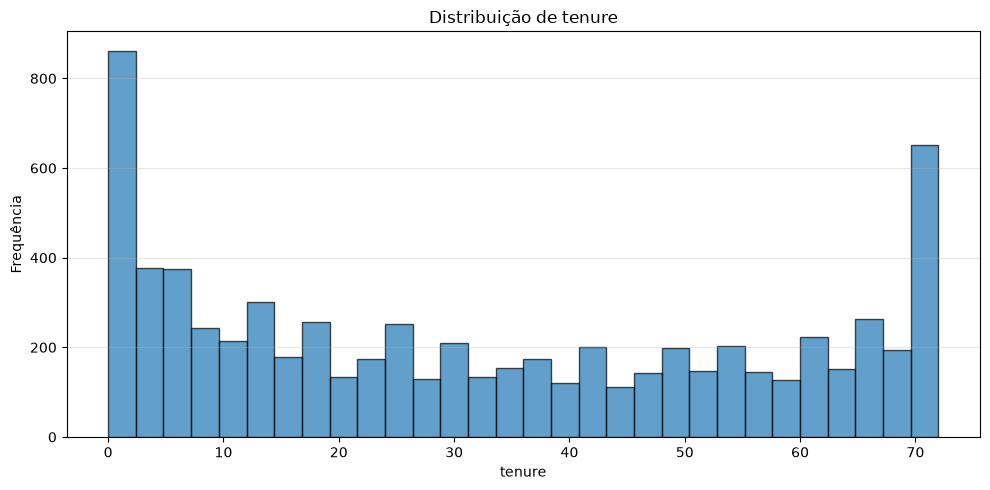

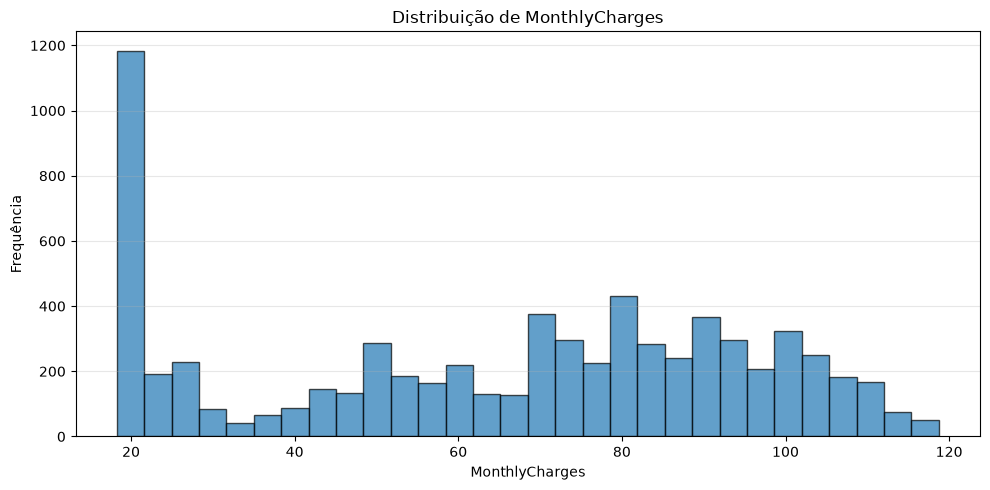

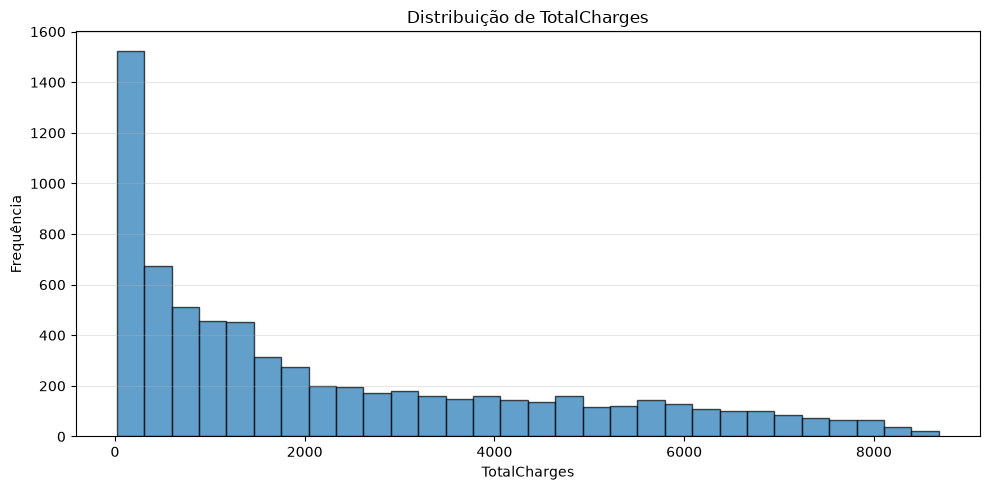


✓ Distribuições numéricas concluídas.


In [51]:
# %%
# ANÁLISE UNIVARIADA — VARIÁVEIS NUMÉRICAS

print("=" * 60)
print("ANÁLISE UNIVARIADA - VARIÁVEIS NUMÉRICAS")
print("=" * 60)

numeric_features_eda = [
    col
    for col in numeric_cols
    if col != "Churn"
]

print("\nVariáveis analisadas:")

for col in numeric_features_eda:
    print(f" - {col}")

for col in numeric_features_eda:

    plt.figure(figsize=(10, 5))

    plt.hist(
        df_numeric[col].dropna(),
        bins=30,
        edgecolor="black",
        alpha=0.7
    )

    plt.title(
        f"Distribuição de {col}"
    )

    plt.xlabel(col)
    plt.ylabel("Frequência")

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    output_path = (
        artifacts_plots_dir /
        f"distribution_{col}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print("\n✓ Distribuições numéricas concluídas.")

In [52]:
# %%
# CORRELAÇÃO DAS VARIÁVEIS NUMÉRICAS COM CHURN

print("=" * 60)
print("CORRELAÇÃO COM CHURN")
print("=" * 60)

correlation_with_churn = (
    df_numeric[numeric_cols]
    .corr()["Churn"]
    .sort_values(
        ascending=False
    )
)

print("\nCorrelação com Churn:")
print(
    correlation_with_churn.round(3)
)

CORRELAÇÃO COM CHURN

Correlação com Churn:
Churn             1.000
MonthlyCharges    0.193
SeniorCitizen     0.151
TotalCharges     -0.199
tenure           -0.352
Name: Churn, dtype: float64


MATRIZ DE CORRELAÇÃO


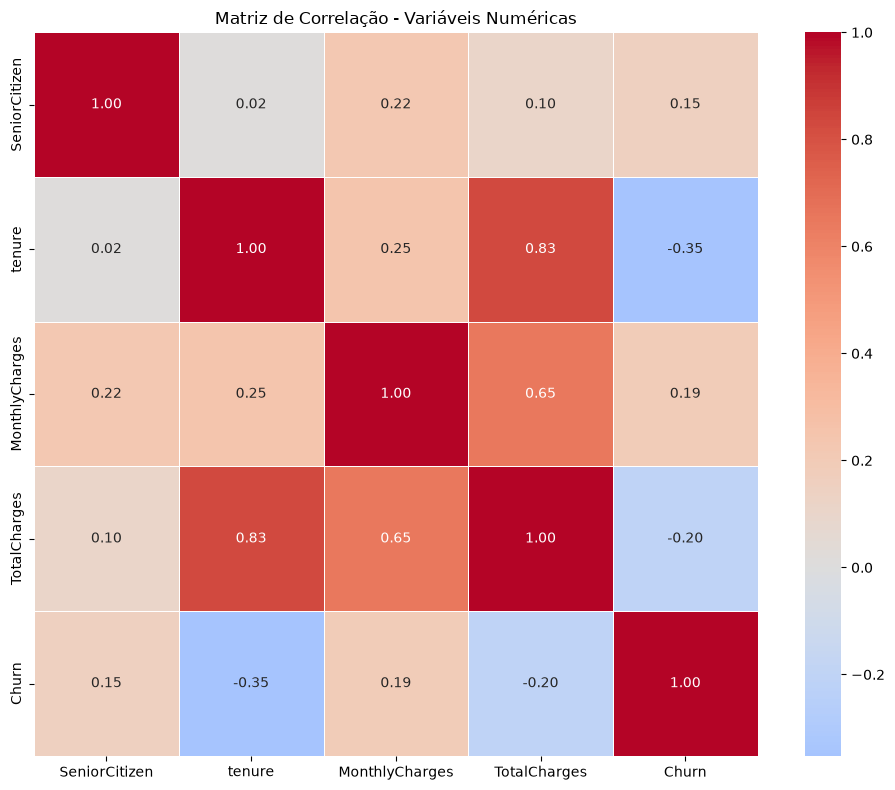


✓ Gráfico salvo em:
c:\Temp\telco-churn-ml\artifacts\plots\03_correlation_heatmap.png


In [53]:
# %%
# MATRIZ DE CORRELAÇÃO

print("=" * 60)
print("MATRIZ DE CORRELAÇÃO")
print("=" * 60)

correlation_matrix = (
    df_numeric[numeric_cols]
    .corr()
)

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Matriz de Correlação - Variáveis Numéricas"
)

plt.tight_layout()

output_path = (
    artifacts_plots_dir /
    "03_correlation_heatmap.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\n✓ Gráfico salvo em:")
print(output_path)

RELAÇÃO TENURE x CHURN


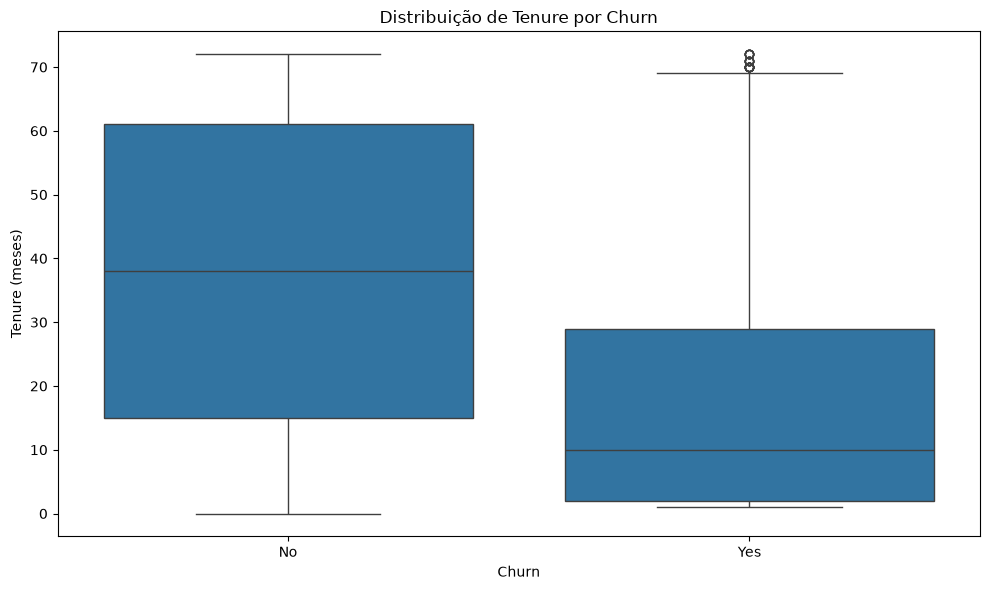


✓ Gráfico salvo em:
c:\Temp\telco-churn-ml\artifacts\plots\04_tenure_churn.png


In [54]:
# %%
# RELAÇÃO TENURE x CHURN

print("=" * 60)
print("RELAÇÃO TENURE x CHURN")
print("=" * 60)

plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title(
    "Distribuição de Tenure por Churn"
)

plt.xlabel("Churn")
plt.ylabel("Tenure (meses)")

plt.tight_layout()

output_path = (
    artifacts_plots_dir /
    "04_tenure_churn.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\n✓ Gráfico salvo em:")
print(output_path)

In [55]:
# %%
# ANÁLISE CONJUNTA:
# TENURE x MONTHLY CHARGES x CHURN

print("=" * 60)
print("ANÁLISE CONJUNTA: TENURE x MONTHLY CHARGES x CHURN")
print("=" * 60)

df_interaction = df.copy()

df_interaction["tenure"] = pd.to_numeric(
    df_interaction["tenure"],
    errors="coerce"
)

df_interaction["MonthlyCharges"] = pd.to_numeric(
    df_interaction["MonthlyCharges"],
    errors="coerce"
)

df_interaction["tenure_group"] = pd.cut(
    df_interaction["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 meses",
        "7-12 meses",
        "13-24 meses",
        "25-48 meses",
        "49-72 meses"
    ]
)

df_interaction["monthly_charge_group"] = pd.qcut(
    df_interaction["MonthlyCharges"],
    q=3,
    labels=[
        "Baixa",
        "Média",
        "Alta"
    ],
    duplicates="drop"
)

interaction_analysis = (
    df_interaction
    .groupby(
        [
            "tenure_group",
            "monthly_charge_group"
        ],
        observed=False
    )
    .agg(
        Clientes=("Churn", "count"),
        Churn=(
            "Churn",
            lambda x: (x == "Yes").sum()
        )
    )
)

interaction_analysis["Taxa_Churn_%"] = (
    interaction_analysis["Churn"]
    / interaction_analysis["Clientes"]
    * 100
).round(2)

display(interaction_analysis)

ANÁLISE CONJUNTA: TENURE x MONTHLY CHARGES x CHURN


Clientes  Churn  Taxa_Churn_%
tenure_group monthly_charge_group                               
0-6 meses    Baixa                      676    248         36.69
             Média                      590    370         62.71
             Alta                       215    166         77.21
7-12 meses   Baixa                      273     46         16.85
             Média                      270     95         35.19
             Alta                       162    112         69.14
13-24 meses  Baixa                      361     38         10.53
             Média                      369    105         28.46
             Alta                       294    151         51.36
25-48 meses  Baixa                      492     27          5.49
             Média                      521     93         17.85
             Alta                       581    205         35.28
49-72 meses  Baixa                      549     14          2.55
             Média                      595     33          5.55
             Alta                      1095    166         15.16

In [56]:
# %%
# COMBINAÇÕES COM MAIOR TAXA DE CHURN

print("=" * 60)
print("COMBINAÇÕES COM MAIOR TAXA DE CHURN")
print("=" * 60)

interaction_sorted = (
    interaction_analysis
    .sort_values(
        "Taxa_Churn_%",
        ascending=False
    )
)

display(
    interaction_sorted.head(10)
)

COMBINAÇÕES COM MAIOR TAXA DE CHURN


,,Clientes,Churn,Taxa_Churn_%
tenure_group,monthly_charge_group,,,
0-6 meses,Alta,215,166,77.21
7-12 meses,Alta,162,112,69.14
0-6 meses,Média,590,370,62.71
13-24 meses,Alta,294,151,51.36
0-6 meses,Baixa,676,248,36.69
25-48 meses,Alta,581,205,35.28
7-12 meses,Média,270,95,35.19
13-24 meses,Média,369,105,28.46
25-48 meses,Média,521,93,17.85


In [57]:
# %%
# SALVAR ANÁLISE DE INTERAÇÃO

interaction_output_path = (
    artifacts_tables_dir /
    "tenure_monthlycharges_churn_analysis.csv"
)

interaction_analysis.to_csv(
    interaction_output_path
)

print("✓ Análise de interação concluída.")

print("\nArquivo salvo em:")
print(interaction_output_path)

✓ Análise de interação concluída.

Arquivo salvo em:
c:\Temp\telco-churn-ml\artifacts\tables\tenure_monthlycharges_churn_analysis.csv


In [58]:
# %%
# INSIGHTS PRINCIPAIS DA EDA

print("=" * 60)
print("INSIGHTS PRINCIPAIS DA EDA")
print("=" * 60)

print("\n1. CHURN")
print(
    f"Taxa geral de churn: "
    f"{churn_rate:.2f}%"
)

print(
    f"Clientes com churn: "
    f"{(df['Churn'] == 'Yes').sum():,}"
)

print(
    f"Clientes sem churn: "
    f"{(df['Churn'] == 'No').sum():,}"
)

print("\n2. TENURE")

print(
    tenure_sorted[
        ["Clientes", "Churn", "Taxa_Churn_%"]
    ].head(5)
)

print("\n3. CATEGORIAS COM MAIOR CHURN")

display(
    ranking_churn[
        [
            "Variavel",
            "Categoria",
            "Clientes",
            "Churn",
            "Taxa_Churn_%"
        ]
    ].head(10)
)

print("\n4. INTERAÇÃO TENURE x MONTHLY CHARGES")

display(
    interaction_sorted.head(10)
)

print("\n✓ Principais resultados da EDA identificados.")

INSIGHTS PRINCIPAIS DA EDA

1. CHURN
Taxa geral de churn: 26.54%
Clientes com churn: 1,869
Clientes sem churn: 5,174

2. TENURE
              Clientes  Churn  Taxa_Churn_%
tenure_group                               
0-6 meses         1481    784         52.94
7-12 meses         705    253         35.89
13-24 meses       1024    294         28.71
25-48 meses       1594    325         20.39
49-72 meses       2239    213          9.51

3. CATEGORIAS COM MAIOR CHURN


,Variavel,Categoria,Clientes,Churn,Taxa_Churn_%
0,PaymentMethod,Electronic check,2365,1071,45.285412
1,Contract,Month-to-month,3875,1655,42.709677
2,InternetService,Fiber optic,3096,1297,41.892765
3,OnlineSecurity,No,3498,1461,41.766724
4,TechSupport,No,3473,1446,41.635474
5,OnlineBackup,No,3088,1233,39.928756
6,DeviceProtection,No,3095,1211,39.127625
7,StreamingMovies,No,2785,938,33.680431
8,PaperlessBilling,Yes,4171,1400,33.565092
9,StreamingTV,No,2810,942,33.523132



4. INTERAÇÃO TENURE x MONTHLY CHARGES


,,Clientes,Churn,Taxa_Churn_%
tenure_group,monthly_charge_group,,,
0-6 meses,Alta,215,166,77.21
7-12 meses,Alta,162,112,69.14
0-6 meses,Média,590,370,62.71
13-24 meses,Alta,294,151,51.36
0-6 meses,Baixa,676,248,36.69
25-48 meses,Alta,581,205,35.28
7-12 meses,Média,270,95,35.19
13-24 meses,Média,369,105,28.46
25-48 meses,Média,521,93,17.85



✓ Principais resultados da EDA identificados.


In [59]:
# %%
# SALVAR RESUMO DA EDA

print("=" * 60)
print("SALVANDO RESUMO DA EDA")
print("=" * 60)

summary_path = (
    reports_dir /
    "EDA_Summary.txt"
)

summary_text = f"""
EDA SUMMARY - TELCO CUSTOMER CHURN
{'=' * 60}

DIMENSÕES DO DATASET
Linhas: {df.shape[0]}
Colunas: {df.shape[1]}

CHURN
Clientes com churn:
{(df['Churn'] == 'Yes').sum()}

Clientes sem churn:
{(df['Churn'] == 'No').sum()}

Taxa de churn:
{churn_rate:.2f}%

BALANCEAMENTO
Classe majoritária:
{churn_counts.idxmax()}

Classe minoritária:
{churn_counts.idxmin()}

Razão majoritária/minoritária:
{imbalance_ratio:.2f}

CORRELAÇÃO COM CHURN
{correlation_with_churn.round(3).to_string()}

TOP CATEGORIAS POR TAXA DE CHURN
{ranking_churn.head(10).to_string(index=False)}

TOP COMBINAÇÕES TENURE x MONTHLY CHARGES
{interaction_sorted.head(10).to_string()}

ARQUIVOS GERADOS
- categorical_churn_analysis.csv
- numeric_churn_analysis.csv
- tenure_churn_analysis.csv
- tenure_monthlycharges_churn_analysis.csv
- 01_churn_distribution.png
- 02_top_categories_churn.png
- 03_correlation_heatmap.png
- 04_tenure_churn.png
"""

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(summary_text)

print("\n✓ Resumo da EDA salvo em:")
print(summary_path)

print("\n" + "=" * 60)
print("ETAPA 2 — EDA CONCLUÍDA")
print("=" * 60)

SALVANDO RESUMO DA EDA

✓ Resumo da EDA salvo em:
c:\Temp\telco-churn-ml\reports\EDA_Summary.txt

ETAPA 2 — EDA CONCLUÍDA
